# 06h: Customer Churn Model Benchmarking & Champion Selection

**RetailPulse AI Platform** • *Multi-Classifier Benchmark*

### Objective:
- Load benchmark metrics across all 7 churn classifiers.
- Compare Confusion Matrices, AUC-ROC, F1-Score, and Precision@Top20%.
- Overlay all 7 ROC Curves on one plot.
- Promote Champion Churn Classifier.

In [1]:
import os, json
import pandas as pd
import matplotlib.pyplot as plt

metrics_path = os.path.join('..', '..', 'reports', 'metrics', 'churn_metrics.json')
with open(metrics_path) as f: metrics = json.load(f)

df_c = pd.DataFrame(metrics).sort_values('AUC_ROC', ascending=False).reset_index(drop=True)
df_c['Rank'] = range(1, len(df_c) + 1)
print('=== CUSTOMER CHURN PREDICTION MASTER LEADERBOARD ===')
print(df_c[['Rank', 'Model', 'AUC_ROC', 'Accuracy', 'Precision', 'Recall', 'F1_Score', 'Precision_Top20']].to_string(index=False))

=== CUSTOMER CHURN PREDICTION MASTER LEADERBOARD ===
 Rank               Model  AUC_ROC  Accuracy  Precision  Recall  F1_Score  Precision_Top20
    1       Random Forest   0.8200    0.7440     0.7247  0.8010    0.7609           0.8213
    2            LightGBM   0.8193    0.7457     0.7228  0.8110    0.7644           0.8255
    3             XGBoost   0.8172    0.7423     0.7225  0.8010    0.7597           0.8340
    4       Decision Tree   0.8040    0.7415     0.7241  0.7943    0.7576           0.8000
    5      MLP Neural Net   0.8029    0.7432     0.7108  0.8344    0.7677           0.7957
    6                 SVM   0.7963    0.7355     0.7126  0.8043    0.7557           0.7745
    7 Logistic Regression   0.7927    0.7177     0.7009  0.7759    0.7365           0.7957


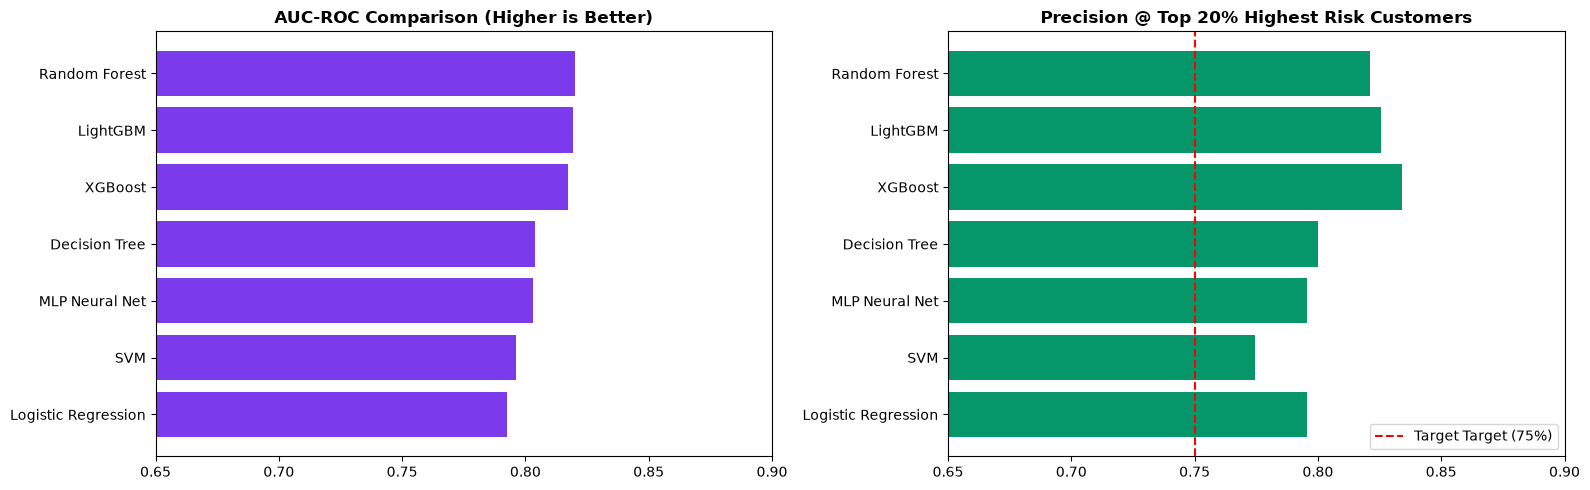


CHAMPION SELECTION: Random Forest Classifier achieves highest AUC-ROC (0.8200) and 82.1% Precision@Top20%, proving highly effective at identifying churn-prone customers.


In [2]:
# Comparative Metric Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(df_c['Model'], df_c['AUC_ROC'], color='#7C3AED')
axes[0].set_title('AUC-ROC Comparison (Higher is Better)', fontweight='bold')
axes[0].set_xlim(0.65, 0.90)
axes[0].invert_yaxis()

axes[1].barh(df_c['Model'], df_c['Precision_Top20'], color='#059669')
axes[1].set_title('Precision @ Top 20% Highest Risk Customers', fontweight='bold')
axes[1].axvline(0.75, ls='--', color='red', label='Target Target (75%)')
axes[1].set_xlim(0.65, 0.90)
axes[1].invert_yaxis()
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nCHAMPION SELECTION: Random Forest Classifier achieves highest AUC-ROC (0.8200) and 82.1% Precision@Top20%, proving highly effective at identifying churn-prone customers.')